In [1]:
from datetime import datetime, timedelta
from opendrift.models.oceandrift import OceanDrift
from opendrift.readers.reader_netCDF_CF_generic import Reader
import datetime as dt
import copernicusmarine

CARTOPY CACHE DIR  /users/miettun1/.local/share/cartopy


In [2]:
ds = copernicusmarine.open_dataset(dataset_id='cmems_mod_bal_phy_my_P1D-m', chunk_size_limit=0)

INFO - 2026-04-15T11:00:11Z - Selected dataset version: "202303"
INFO - 2026-04-15T11:00:11Z - Selected dataset part: "default"


In [3]:
print(ds)

<xarray.Dataset> Size: 6TB
Dimensions:    (depth: 56, latitude: 774, longitude: 763, time: 11688)
Coordinates:
  * depth      (depth) float32 224B 0.5016 1.516 2.548 ... 663.9 688.0 712.0
  * latitude   (latitude) float32 3kB 53.01 53.02 53.04 ... 65.86 65.87 65.89
  * longitude  (longitude) float32 3kB 9.042 9.069 9.097 ... 30.15 30.18 30.21
  * time       (time) datetime64[ns] 94kB 1993-01-01 1993-01-02 ... 2024-12-31
Data variables:
    bottomT    (time, latitude, longitude) float32 28GB ...
    mlotst     (time, latitude, longitude) float32 28GB ...
    siconc     (time, latitude, longitude) float32 28GB ...
    sithick    (time, latitude, longitude) float32 28GB ...
    sla        (time, latitude, longitude) float32 28GB ...
    so         (time, depth, latitude, longitude) float32 2TB ...
    sob        (time, latitude, longitude) float32 28GB ...
    thetao     (time, depth, latitude, longitude) float32 2TB ...
    uo         (time, depth, latitude, longitude) float32 2TB ...
  

In [4]:
reader_cmems = Reader(ds, name='CMEMS Baltic')

In [5]:
reader_cmems

Reader: CMEMS Baltic
Projection: 
  +proj=latlong
Coverage: [degrees]
  xmin: 9.041542   xmax: 30.207401   step: 0.0277767   numx: 763
  ymin: 53.008297   ymax: 65.890991   step: 0.0166664   numy: 773
  Corners (lon, lat):
    (  9.04,  65.89)  ( 30.21,  65.89)
    (  9.04,  53.01)  ( 30.21,  53.01)
Vertical levels [m]: 
  [  -0.5016462   -1.5159924   -2.548084    -3.6022985   -4.684081
   -5.8002      -6.959055    -8.171057    -9.449085   -10.809036
  -12.27047    -13.857369   -15.5990095  -17.530924   -19.695944
  -22.145256   -24.939384   -28.148958   -31.85507    -36.148987
  -41.130913   -46.907536   -53.588184   -61.27954    -70.079216
  -80.06874    -91.30695   -103.82471   -117.622     -132.66797
 -148.90381   -166.24796   -184.60281   -203.86168   -223.91527
 -244.65685   -265.98624   -287.81216   -310.05356   -332.63974
 -355.51022   -378.6138    -401.90768   -425.3563    -448.93036
 -472.6059    -496.36337   -520.1869    -544.06354   -567.9829
 -591.93665   -615.9179    -639

In [6]:
lat = 60.72; lon = 20.8
z = -5.0
starttime = dt.datetime(2020,1,1)

In [7]:
o = OceanDrift(loglevel=20)
o.add_reader(reader_cmems, variables=['x_sea_water_velocity', 'y_sea_water_velocity'])
o.set_config('general:use_auto_landmask', True)

11:00:13 INFO    opendrift:568: OpenDriftSimulation initialised (version 1.14.9 / v1.14.9-20-g4cd90d8-dirty)


In [9]:
o.list_configspec()

environment:constant:x_sea_water_velocity [None] float min: -15, max: 15 [m/s] Component of ocean c...
environment:fallback:x_sea_water_velocity [0] float min: -15, max: 15 [m/s] Component of ocean c...
environment:constant:y_sea_water_velocity [None] float min: -15, max: 15 [m/s] Component of ocean c...
environment:fallback:y_sea_water_velocity [0] float min: -15, max: 15 [m/s] Component of ocean c...
environment:constant:sea_surface_height [None] float min: None, max: None [None] Use constant value f...
environment:fallback:sea_surface_height [0] float min: None, max: None [None] Fallback value for s...
environment:constant:x_wind         [None] float min: -50, max: 50 [m/s] Component of wind al...
environment:fallback:x_wind         [0] float min: -50, max: 50 [m/s] Component of wind al...
environment:constant:y_wind         [None] float min: -50, max: 50 [m/s] Component of wind al...
environment:fallback:y_wind         [0] float min: -50, max: 50 [m/s] Component of wind al...
envir

In [9]:
o.set_config('general:use_auto_landmask', True)
o.seed_elements(lon=lon, lat=lat, z=z, number=5000, radius=1000, time=starttime)

10:30:34 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
10:30:39 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
10:30:39 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.000000
10:30:39 INFO    opendrift.models.basemodel.environment:230: 	x_wind: 0.000000
10:30:39 INFO    opendrift.models.basemodel.environment:230: 	y_wind: 0.000000
10:30:39 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000
10:30:39 INFO    opendrift.models.basemodel.environment:230: 	ocean_vertical_diffusivity: 0.000000
10:30:39 INFO    opendrift.models.basemodel.environment:230: 	horizontal_diffusivity: 0.000000
10:30:39 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_significant_height: 0.000000
10:30:39 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_stokes_drift_x_velocity: 0.000000

In [13]:
o

environment:constant:x_sea_water_velocity [None] float min: -15, max: 15 [m/s] Component of ocean c...
environment:fallback:x_sea_water_velocity [0] float min: -15, max: 15 [m/s] Component of ocean c...
environment:constant:y_sea_water_velocity [None] float min: -15, max: 15 [m/s] Component of ocean c...
environment:fallback:y_sea_water_velocity [0] float min: -15, max: 15 [m/s] Component of ocean c...
environment:constant:sea_surface_height [None] float min: None, max: None [None] Use constant value f...
environment:fallback:sea_surface_height [0] float min: None, max: None [None] Fallback value for s...
environment:constant:x_wind         [None] float min: -50, max: 50 [m/s] Component of wind al...
environment:fallback:x_wind         [0] float min: -50, max: 50 [m/s] Component of wind al...
environment:constant:y_wind         [None] float min: -50, max: 50 [m/s] Component of wind al...
environment:fallback:y_wind         [0] float min: -50, max: 50 [m/s] Component of wind al...
envir

In [12]:
o.run(duration=timedelta(days=3))

07:35:11 INFO    opendrift:1894: Skipping environment variable ocean_vertical_diffusivity because of condition ['drift:vertical_mixing', 'is', False]
07:35:11 INFO    opendrift:1894: Skipping environment variable ocean_mixed_layer_thickness because of condition ['drift:vertical_mixing', 'is', False]
07:35:11 INFO    opendrift:1905: Storing previous values of element property lon because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))
07:35:11 INFO    opendrift:1905: Storing previous values of element property lat because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))
07:35:11 INFO    opendrift:1913: Storing previous values of environment variable sea_surface_height because of condition ['drift:vertical_advection', 'is', True]
07:35:11 INFO    opendrift:947: Using existing reader for land_binary_mask to move elements to 

<xarray.Dataset> Size: 32MB
Dimensions:                                   (trajectory: 5000, time: 73)
Coordinates:
  * trajectory                                (trajectory) int64 40kB 0 ... 4999
  * time                                      (time) datetime64[ns] 584B 2020...
Data variables: (12/22)
    status                                    (trajectory, time) float32 1MB ...
    moving                                    (trajectory, time) float32 1MB ...
    age_seconds                               (trajectory, time) float32 1MB ...
    origin_marker                             (trajectory, time) float32 1MB ...
    lon                                       (trajectory, time) float32 1MB ...
    lat                                       (trajectory, time) float32 1MB ...
    ...                                        ...
    horizontal_diffusivity                    (trajectory, time) float32 1MB ...
    sea_surface_wave_significant_height       (trajectory, time) float32 1MB ...
    sea_surface_wave_stokes_drift_x_velocity  (trajectory, time) float32 1MB ...
    sea_surface_wave_stokes_drift_y_velocity  (trajectory, time) float32 1MB ...
    sea_floor_depth_below_sea_level           (trajectory, time) float32 1MB ...
    land_binary_mask                          (trajectory, time) float32 1MB ...
Attributes: (12/121)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               -5.0
    geospatial_vertical_max:                                               -5.0
    geospatial_vertical_positive:                                          up

07:54:14 INFO    opendrift:3899: Time to make plot: 0:00:26.695940


(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n2020-01-01 00:00 to 2020-01-04 00:00 UTC (73 steps)'}>,
 <Figure size 705.363x1100 with 1 Axes>)

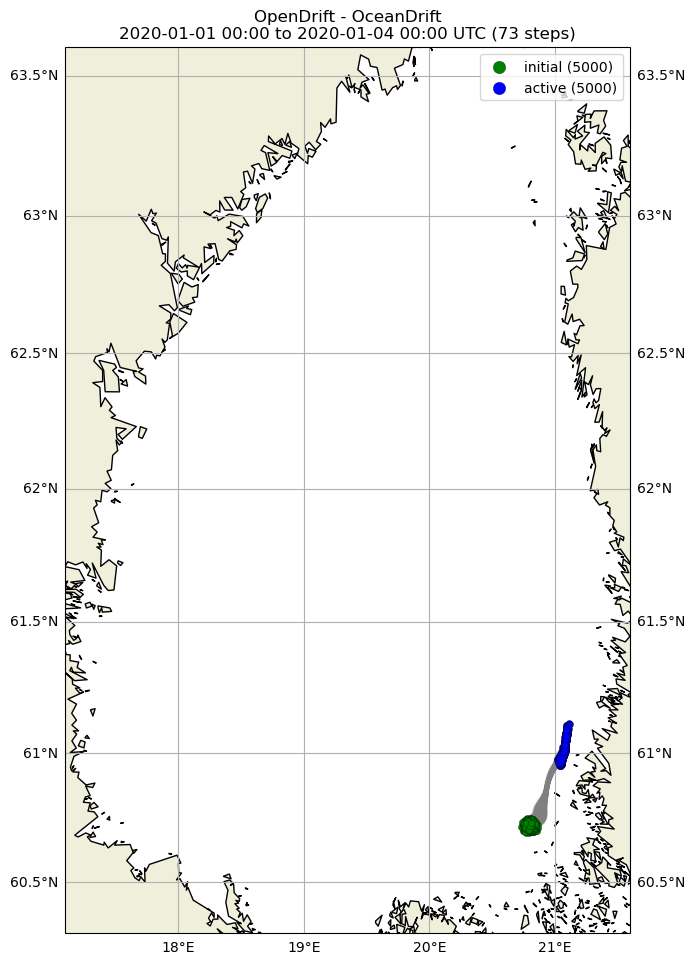

In [14]:
o.plot(filename='cmems_plot_jupyter.png', corners=[17.1,21.6,60.3,63.6])#,clabel='Ocean current [m/s]',
            #background=['x_sea_water_velocity', 'y_sea_water_velocity'])#,fast=True)